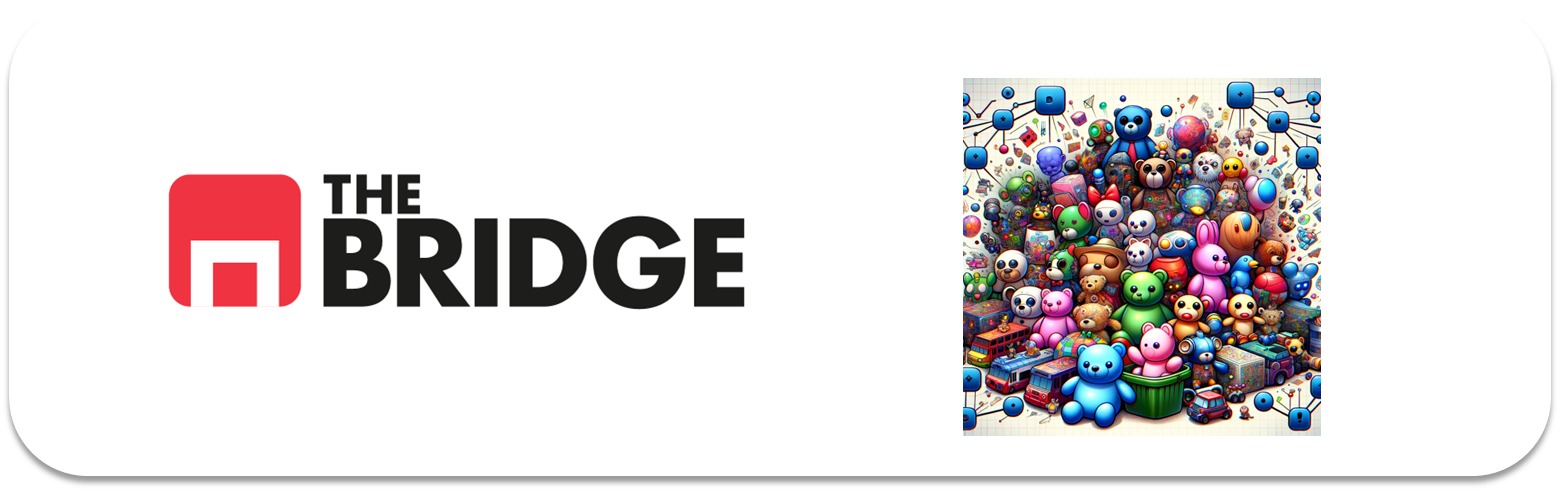

## PRACTICA OBLIGATORIA: **DBSCAN y Clustering Jerárquico**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado aplicado a clustering jerárquico y no jerárquico. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [30]:
import bootcampviztools as bt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.cluster.hierarchy as shc
from scipy.cluster.hierarchy import fcluster

from sklearn.cluster import DBSCAN

### Parte I. Modelado

#### Descripción del problema.

En una planta de experimentación con nuevas bebidas energéticas están trabajando con diferentes mezclas de componentes para obtener posibles variedades de su producto estrella "NonstopU". El problema es que la fabricación de cada "prototipo" conlleva demasiado tiempo y las pruebas de sabores y de propiedades "non-stop" antisueño y antifatiga son costosas.  

En ese sentido quieren construir algún sistema de segmentación previa de mezclas sin probarlas solo indicando las cantidades de cada componente de la bebida. Tienen datos pero desgraciadamente de mezclas anteriores con diferentes medidas pero que por temas presupuestarios y de prioridad no se hicieron test con usuarios y potenciales clientes, es decir no tienen un target de capacidad antifatiga o de preferncia del usuario que puedas servirles para construir un clasificador clásico como han hecho otras veces.  

Han acudido a vosotros con la necesida de encontrar ese segmentador de posibles bebidas y con los datos de las mezclas no probadas anteriores por ver si vostros podéis ayudarles a encontrar algún tipo de segmentación que luego ello se encargarían de interpretar. No es requisito obligatorio pero les gustaría también poder establecer algún tipo de relación entre las segmentaciones (tipo cuales segmentos se "parecerían" más entre sí)

NOTA ORIENTATIVA: Los químicos no esperan que haya menos de 3 segmentos ni más de 5.  
NOTA OPERATIVA: El dataset con los datos que nos han dado los químicos está en "./data/empowering_drinks.csv"

**Se pide**: Construir al menos dos algoritmos de clustering (DBSCAN debe ser uno de ellos y el otro debería estar claro cual deberíamos usar dado el enunciado). Compararlos brevemente aunque sea meramente especulativo (¿Por qué es espculativo?)

**Se recomienda**: Visualizar las features dos a dos para escoger las mejores, no necesariamente hay que usar todas, ni tampoco quedarse en dos. Probar diferentes hiperparámetros en función de la nota orientativa y explicar porqué se han escogido los que finalmente se hayan escogido. 

Recuerda que el proceso es similar a lo que vimos en el otro tipo de aprendizaje:
1. Entender el problema
2. Cargar datos, visualizar.
3. MiniEDA: Selección de features
4. Tratamiento de Features.
5. Selección de modelos, selección de hiperparámetros
6. Entrenamiento, visualización de resultados.
7. Discusión de los mismos


In [31]:
df = pd.read_csv("./data/empowering_drinks.csv", sep="|")

In [32]:
df.head()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.518613,0.232053,1.034819,1.013009,0.251717
1,0.246290,-0.827996,0.733629,0.965242,-0.293321
2,0.196879,1.109334,1.215533,1.395148,0.269020
3,1.691550,0.487926,1.466525,2.334574,1.186068
4,0.295700,1.840403,0.663351,-0.037874,-0.319276


In [33]:
df.describe()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
count,153.000000,153.000000,153.000000,153.000000,153.000000
mean,0.019231,0.037273,0.041057,0.080022,-0.044088
std,1.026182,0.995984,1.040928,1.009450,0.934399
min,-2.434235,-3.679162,-1.695971,-1.493188,-1.634288
25%,-0.816038,-0.499016,-1.043392,-0.738463,-0.799428
50%,0.061000,-0.023821,0.211566,-0.165254,-0.154899
75%,0.876275,0.707247,0.894264,0.917474,0.493956
max,2.259772,3.156325,3.062832,2.971473,2.431870


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Azúcares               153 non-null    float64
 1   Vitamínas del grupo B  153 non-null    float64
 2   Cafeína                153 non-null    float64
 3   Ácido Cítrico          153 non-null    float64
 4   Taurina                153 non-null    float64
dtypes: float64(5)
memory usage: 6.1 KB


#### **Mini-EDA:**

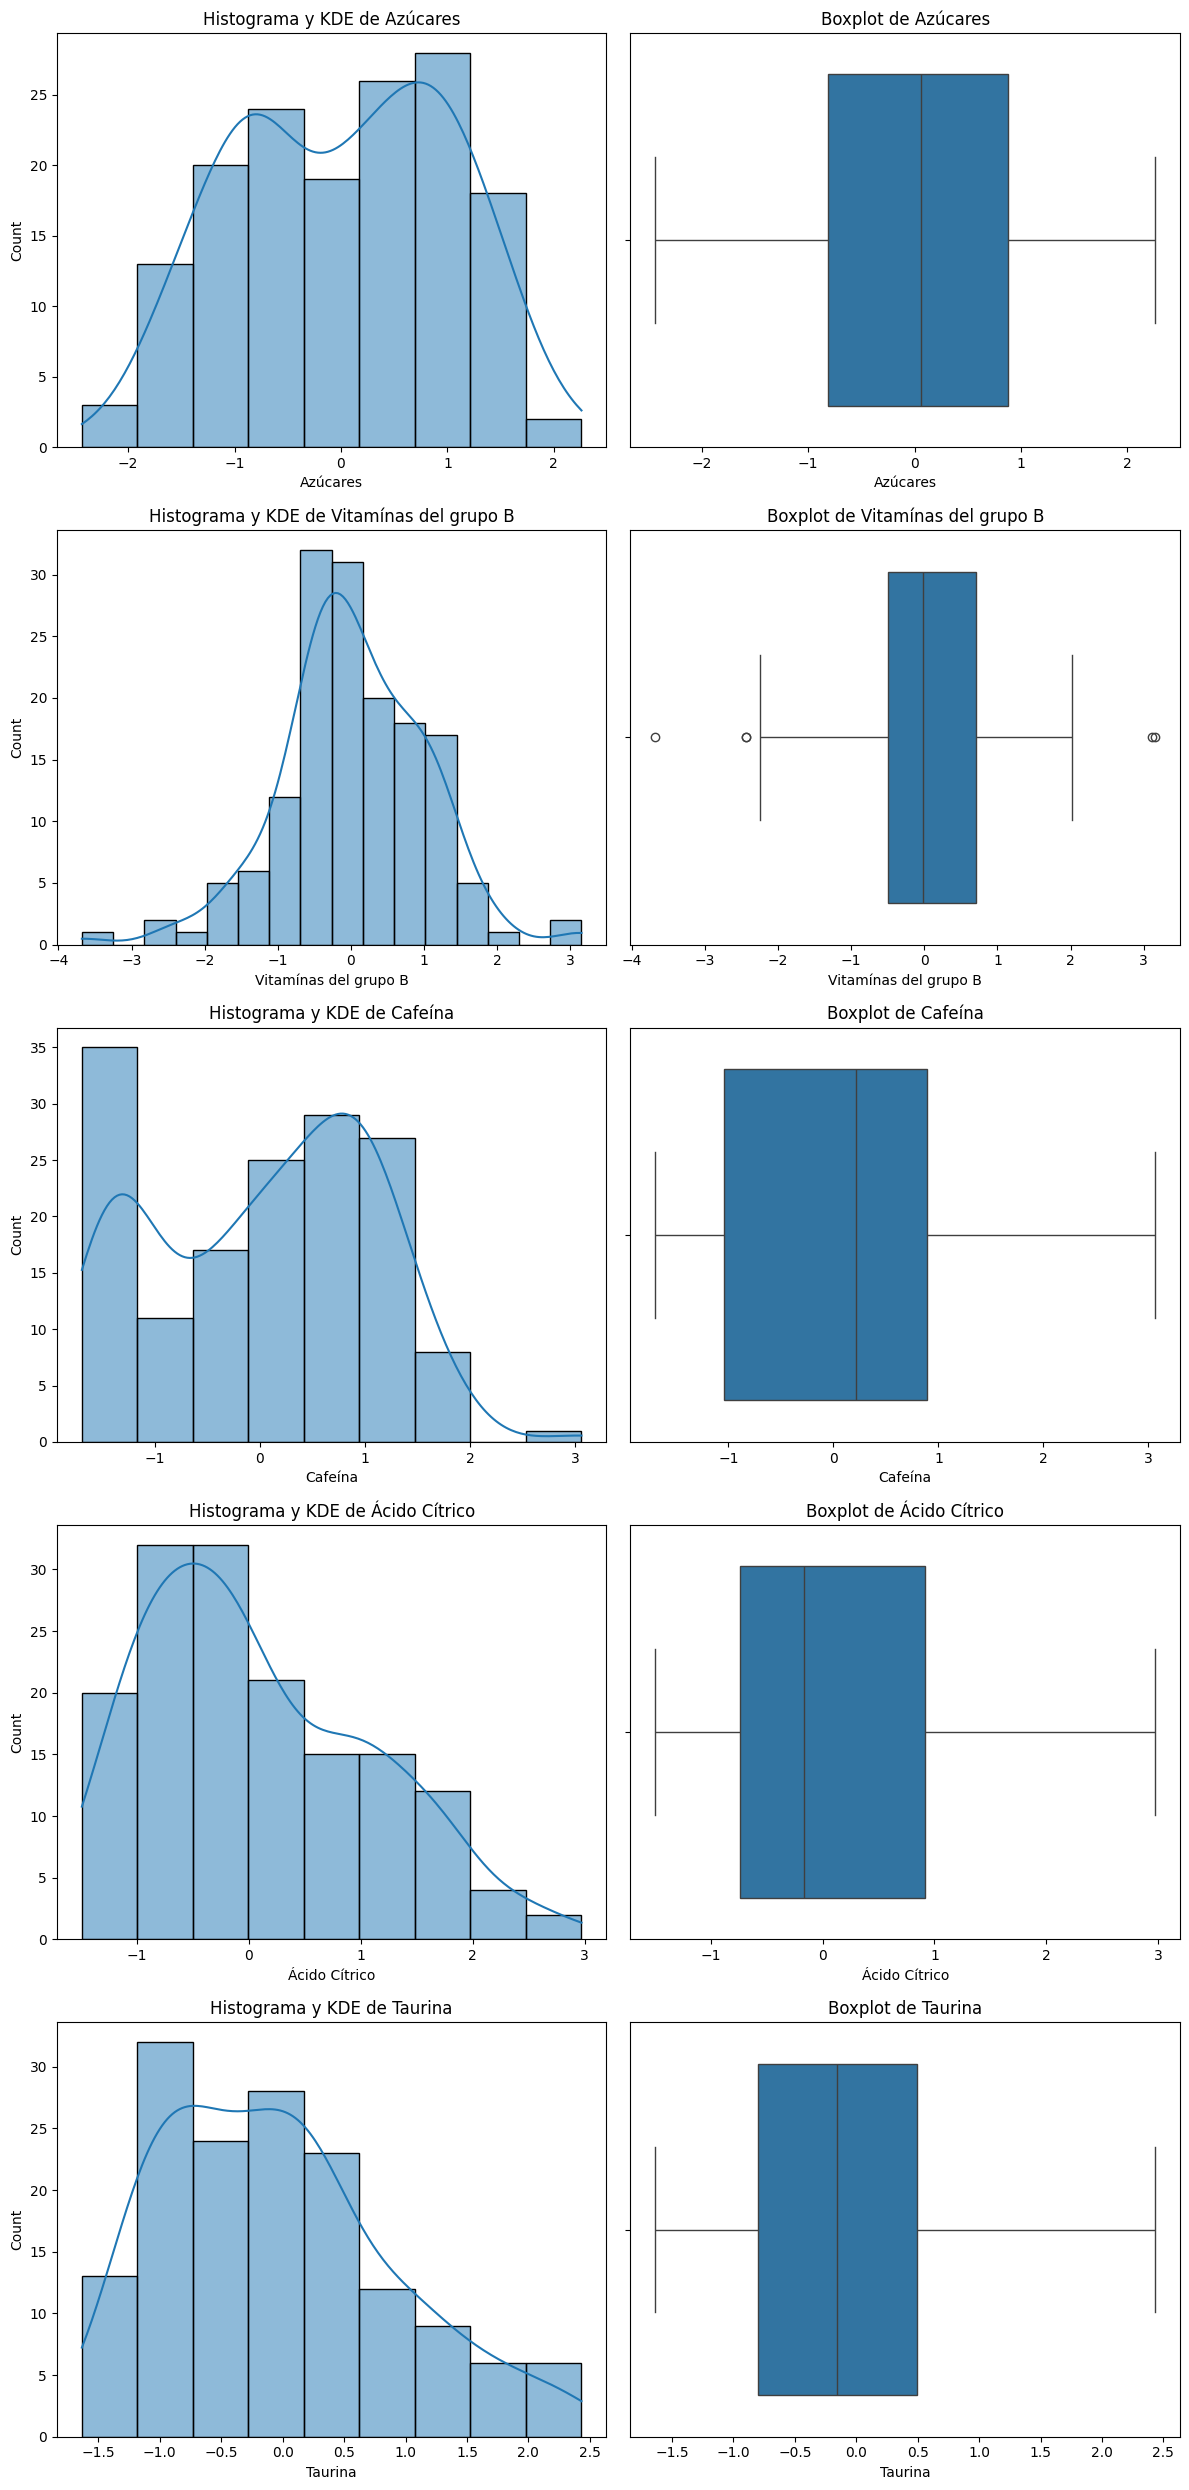

In [35]:
bt.plot_combined_graphs(df, df.columns.to_list())

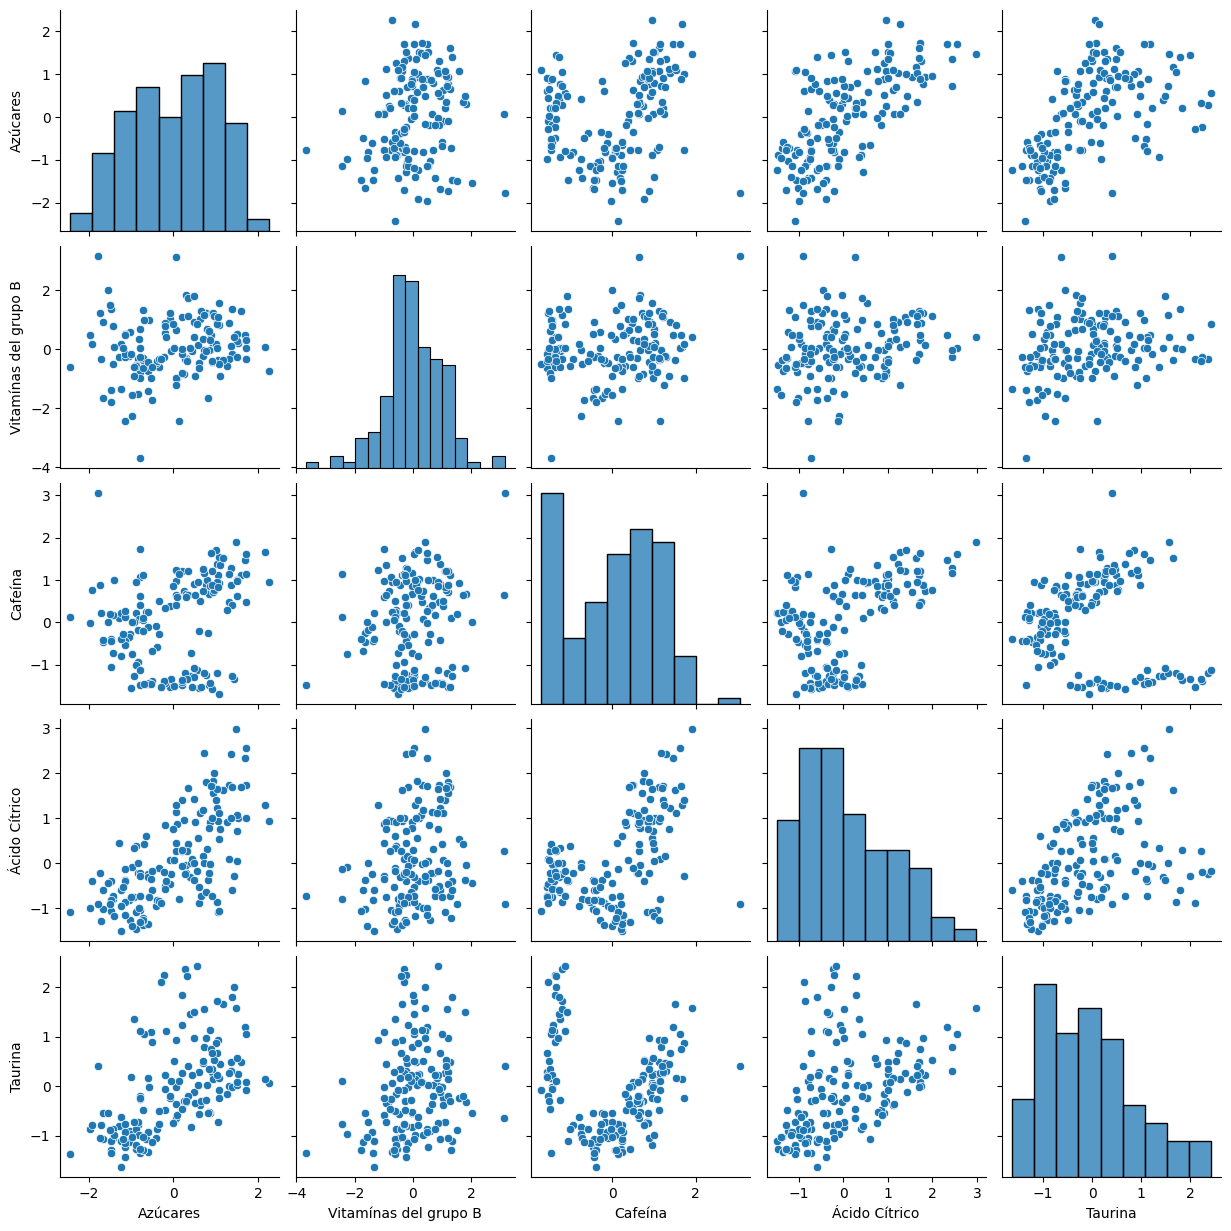

In [36]:
sns.pairplot(df)
plt.show()

La representación de las variables dos a dos no muestra una separación completamente definida entre observaciones, aunque sí se aprecian algunas estructuras que podrían corresponder a distintos grupos. Las combinaciones Cafeína-Taurina y Cafeína-Azúcares son las que presentan una mayor diferenciación visual, observándose distintas concentraciones de puntos que podrían ser aprovechadas por los algoritmos de clustering. En cambio, la variable Vitaminas del grupo B no parece mostrar una capacidad de separación evidente cuando se analiza de forma bivariante, aunque se mantiene en el conjunto de datos al poder aportar información en un espacio multidimensional.

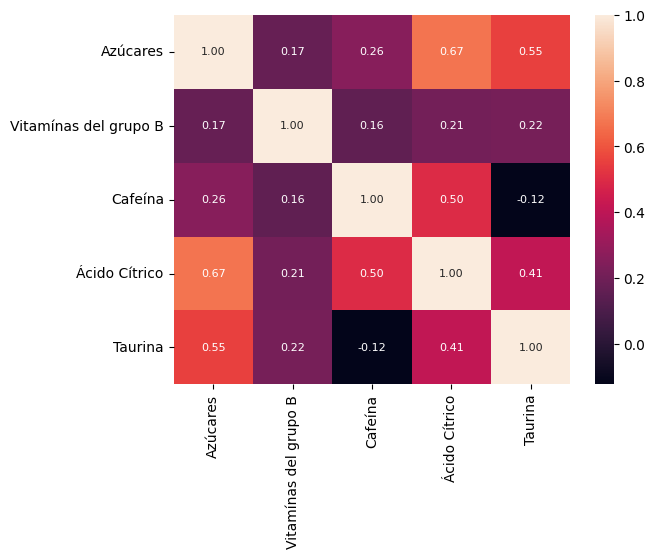

In [37]:
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", annot_kws={"size": 8});

#### **DBSCAN:**

In [38]:
X = df.copy()

In [39]:
dbscan_base = DBSCAN(eps=0.5,
                min_samples=5)
dbscan_base.fit(X)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.5
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",5
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [40]:
print(dbscan_base)

print(np.unique(dbscan_base.labels_))

DBSCAN()
[-1]


In [41]:
pd.Series(dbscan_base.labels_).value_counts().sort_index()

-1    153
Name: count, dtype: int64

In [42]:
for eps in [0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.5]:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()

    print(f"eps={eps:.1f} -> clusters={n_clusters}, ruido={n_noise}")

eps=0.7 -> clusters=3, ruido=122
eps=0.8 -> clusters=8, ruido=80
eps=0.9 -> clusters=5, ruido=54
eps=1.0 -> clusters=3, ruido=28
eps=1.1 -> clusters=2, ruido=13
eps=1.2 -> clusters=1, ruido=8
eps=1.3 -> clusters=1, ruido=6
eps=1.5 -> clusters=1, ruido=4


In [43]:
dbscan = DBSCAN(eps=1.0, min_samples=5)

X_db = dbscan.fit_predict(X)

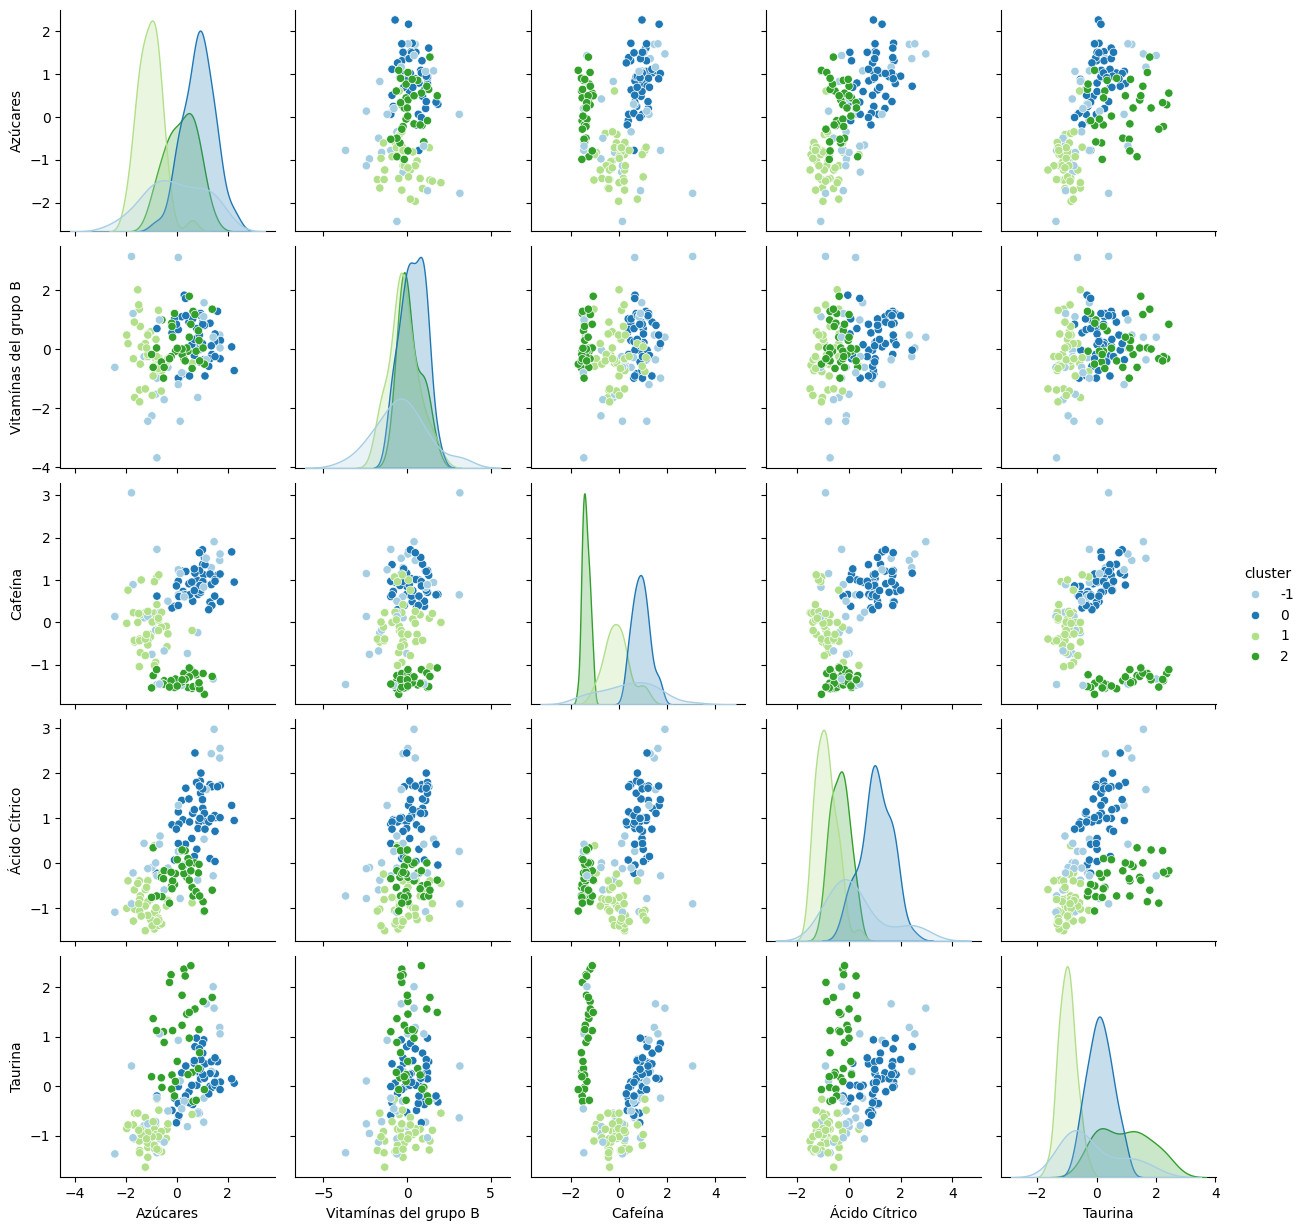

In [44]:
df_pair = pd.DataFrame(X, columns=df.columns)   # si X proviene de df
df_pair["cluster"] = dbscan.labels_             # o X_db

sns.pairplot(
    df_pair,
    hue="cluster",
    palette="Paired"
)

plt.show()

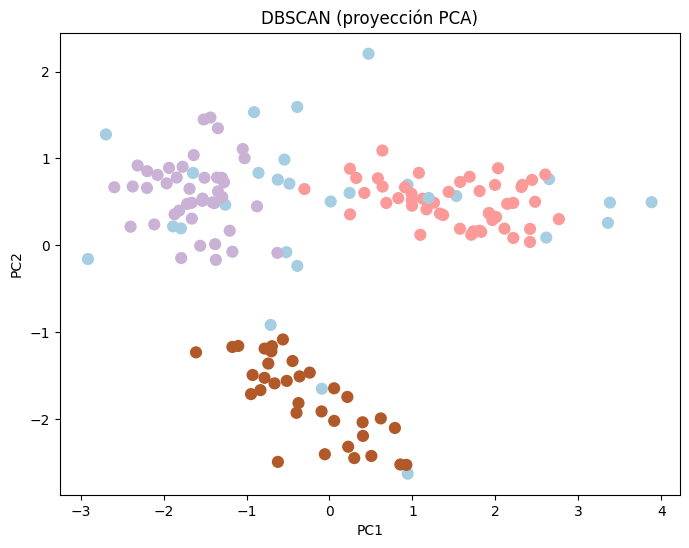

In [45]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=dbscan.labels_,
    cmap="Paired",
    s=60
)

plt.title("DBSCAN (proyección PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Para facilitar la interpretación visual, los resultados del algoritmo se representan sobre una proyección PCA en dos componentes principales. La asignación de clústeres, sin embargo, se ha realizado utilizando las cinco variables originales.

In [46]:
n_noise = (dbscan.labels_ == -1).sum()
print(f"Ruido: {n_noise} ({100*n_noise/len(X):.1f}%)")

Ruido: 28 (18.3%)


In [47]:
from sklearn.metrics import silhouette_score

mask = dbscan.labels_ != -1

silhouette_score(X[mask], dbscan.labels_[mask])

0.4550924838789105

Resultados DBSCAN:
- Número de clusters: 3
- Ruido: 28 (18.3%)
- Silhouette Score: 0.4550


#### **Jerárquico:**

In [20]:
selected_data = X

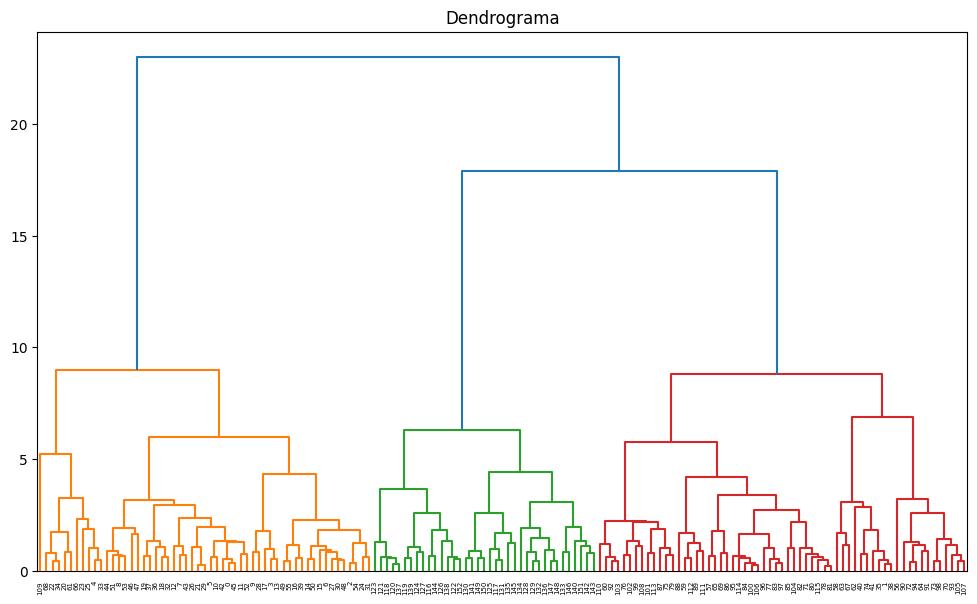

In [21]:
plt.figure(figsize=(12, 7))
plt.title("Dendrograma")

clusters = shc.linkage(
    selected_data,
    method="ward",
    metric="euclidean"
)

shc.dendrogram(clusters)

plt.show()

In [22]:
for k in [3, 4, 5]:
    labels = fcluster(clusters, t=k, criterion="maxclust")
    score = silhouette_score(X, labels)
    print(f"{k} clusters -> {score:.3f}")

3 clusters -> 0.384
4 clusters -> 0.337
5 clusters -> 0.304


#### **Conclusiones DBSCAN vs Jerárquico:**

El coeficiente de silueta obtenido por DBSCAN es superior al del método jerárquico. No obstante, esta comparación debe interpretarse con cautela, ya que DBSCAN considera un 18,3 % de las observaciones como ruido y dichas muestras no intervienen en el cálculo del coeficiente de silueta, mientras que el método jerárquico asigna todas las observaciones a alguno de los clústeres.

---

### Parte II. Nuevos experimentos

Los químicos están muy esperanzados con los modelos que les habéis mostrado y os pasan una lista de nuevos experimentos para que los clasifiquéis. Emplea uno de los modelos construidos, el que te resulte más sencillo, para segmentar los nuevos experimentos que puedes encontrar en "./data/new_experiments.csv"

In [23]:
df_new = pd.read_csv("./data/new_experiments.csv", sep="|")

In [24]:
X_new = df_new.copy()

In [25]:
X_db_new = dbscan.fit_predict(X_new)

In [26]:
pd.Series(dbscan.labels_).value_counts().sort_index()

-1    6
Name: count, dtype: int64

In [27]:
df_new.shape

(6, 5)

Debido a que DBSCAN no implementa un método predict(), no es posible asignar directamente nuevas observaciones a los clústeres obtenidos durante el entrenamiento. La única alternativa es volver a ejecutar el algoritmo sobre los nuevos datos (o sobre el conjunto combinado de datos originales y nuevos), lo que implica recalcular completamente los clústeres y no utilizar el modelo previamente obtenido.

### Parte III. EXTRA (Voluntario): 6 meses después...

La unidad de experimentación recibió un presupuesto adicional gracias a los modelos que les proporcionastes e hizo pruebas con cliente y obtuvo resultados como para clasificar cada bebida en terminos de "energización" en tres niveles (1, media; 2, media-alta, 3, alta). El resultado de los mismos está en el fichero adecuado en el directorio data y alineado con los experimentos iniciales y al final con los nuevos experimentos de la parte anterior.

Evalua la segmentación de los modelos creados en la primera parte.